# ML Filter for Reversal Strategy -- MOEX

Binary classifier trained on IS data (2023--2024) to separate profitable from losing trades among signals with `decline_thr = -12%`. Baseline strategy (nb15): OOS 85 trades, +0.23% avg, Sharpe ~0.6. If ML filters out the bottom 50% of signals and the remaining half has a higher win rate, it improves the OOS Sharpe. Models: Logistic Regression and LightGBM, evaluated with TimeSeriesSplit CV. Data: AlgoPack features + rolling OFI/TFI metrics.


In [11]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import roc_auc_score
import lightgbm as lgb

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

TICKERS = [
    'AFLT','ALRS','AQUA','BANE','BANEP','BSPB','CHMF','ENRU','FEES','FESH',
    'FIVE','GAZP','GMKN','IRAO','LKOH','LSNGP','LSRG','MAGN','MGNT','MOEX',
    'MRKS','MSNG','MTSS','MVID','NLMK','NVTK','OZON','PHOR','PLZL','POLY',
    'POSI','QIWI','RENI','ROSN','RUAL','SBER','SBERP','SELG','SNGS','SNGSP',
    'TATN','TATNP','TCSG','TRMK','TRNFP','VKCO','VTBR','YNDX'
]

BASE_DIR   = '/Users/aakhrameshin/Documents/Side projects/ru_trade'
TMP_DIR    = '/tmp/ru_trade_algopack'
COST_RT    = 0.0036
TRAIN_END  = '2024-12-31'
TEST_START = '2025-01-01'

# Параметры стратегии
DECLINE_THR = -0.12
RVOL_MIN    =  0.25
RVOL_MAX    =  0.60
SPREAD_MAX  =  50.0
HOLD_DAYS   =  5
N_POS       =  5

print('Настройки загружены.')

Настройки загружены.


In [12]:

def copy_to_tmp(table, ticker):
    src = f'{BASE_DIR}/data/cache/algopack/{table}/{ticker}.parquet'
    dst = f'{TMP_DIR}/{table}/{ticker}.parquet'
    os.makedirs(os.path.dirname(dst), exist_ok=True)
    if not os.path.exists(dst) or os.path.getsize(dst) != os.path.getsize(src):
        with open(src, 'rb') as f:
            data = f.read()
        with open(dst, 'wb') as f:
            f.write(data)
    return dst

def load_table(table):
    frames = []
    for t in TICKERS:
        src = f'{BASE_DIR}/data/cache/algopack/{table}/{t}.parquet'
        if not os.path.exists(src):
            continue
        frames.append(pd.read_parquet(copy_to_tmp(table, t)))
    df = pd.concat(frames, ignore_index=True)
    df['ts'] = pd.to_datetime(df['ts'])
    return df.sort_values(['ticker', 'ts']).reset_index(drop=True)

print('Загрузка...')
ts_raw = load_table('tradestats')
ob_raw = load_table('obstats')
or_raw = load_table('orderstats')
print(f'tradestats: {len(ts_raw):,} | obstats: {len(ob_raw):,} | orderstats: {len(or_raw):,}')

# Futoi (открытый интерес по фьючерсам) -- опционально
fi_frames = []
for t in TICKERS:
    src = f'{BASE_DIR}/data/cache/algopack/futoi/{t}.parquet'
    if os.path.exists(src):
        fi_frames.append(pd.read_parquet(copy_to_tmp('futoi', t)))
if fi_frames:
    futoi_raw = pd.concat(fi_frames, ignore_index=True)
    futoi_raw['ts'] = pd.to_datetime(futoi_raw['ts'])
    futoi_raw = futoi_raw.sort_values(['ticker', 'ts']).reset_index(drop=True)
    has_futoi = True
    print(f'futoi:      {len(futoi_raw):,}')
    print('Колонки futoi:', futoi_raw.columns.tolist())
else:
    has_futoi = False
    print('futoi: файлы не найдены')

# Смотрим какие колонки доступны в tradestats и obstats
print('\ntradestats колонки:', ts_raw.columns.tolist())
print('obstats колонки:  ', ob_raw.columns.tolist())

Загрузка...
tradestats: 6,857,289 | obstats: 7,016,134 | orderstats: 7,009,647
futoi: файлы не найдены

tradestats колонки: ['tradedate', 'tradetime', 'secid', 'pr_open', 'pr_high', 'pr_low', 'pr_close', 'pr_std', 'vol', 'val', 'trades', 'pr_vwap', 'pr_change', 'trades_b', 'trades_s', 'val_b', 'val_s', 'vol_b', 'vol_s', 'disb', 'pr_vwap_b', 'pr_vwap_s', 'SYSTIME', 'sec_pr_open', 'sec_pr_high', 'sec_pr_low', 'sec_pr_close', 'ts', 'ticker']
obstats колонки:   ['tradedate', 'tradetime', 'secid', 'spread_bbo', 'spread_lv10', 'spread_1mio', 'levels_b', 'levels_s', 'vol_b', 'vol_s', 'val_b', 'val_s', 'imbalance_vol_bbo', 'imbalance_val_bbo', 'imbalance_vol', 'imbalance_val', 'vwap_b', 'vwap_s', 'vwap_b_1mio', 'vwap_s_1mio', 'SYSTIME', 'ts', 'ticker']


In [13]:

# tradestats: добавляем high/low, value imbalance, trade count
ts_cols = ts_raw.columns.tolist()
agg_dict = dict(
    open=('pr_open','first'), close=('pr_close','last'),
    high=('pr_high','max'),   low=('pr_low','min'),
    tfi_median=('disb','median'),
    intraday_vol=('pr_close','std'),
    vol_total=('vol','sum'), val_total=('val','sum'),
    n_bars=('pr_close','count'),
)
if 'disb_val' in ts_cols:
    agg_dict['tfi_val_median'] = ('disb_val', 'median')
if 'val_b' in ts_cols:
    agg_dict['val_b_total'] = ('val_b', 'sum')
    agg_dict['val_s_total'] = ('val_s', 'sum')
if 'trades' in ts_cols:
    agg_dict['trades_total'] = ('trades', 'sum')

ts_daily = (
    ts_raw.assign(date=ts_raw['ts'].dt.date)
    .groupby(['ticker','date'])
    .agg(**agg_dict)
    .reset_index()
)
ts_daily['date'] = pd.to_datetime(ts_daily['date'])

# obstats: добавляем imbalance_val (OFI по стоимости)
ob_cols = ob_raw.columns.tolist()
ob_agg = dict(
    ofi_vol_median=('imbalance_vol','median'),
    spread_bbo_q80=('spread_bbo', lambda x: x.quantile(0.8)),
)
if 'imbalance_val' in ob_cols:
    ob_agg['ofi_val_median'] = ('imbalance_val', 'median')

ob_daily = (
    ob_raw.assign(date=ob_raw['ts'].dt.date)
    .groupby(['ticker','date'])
    .agg(**ob_agg)
    .reset_index()
)
ob_daily['date'] = pd.to_datetime(ob_daily['date'])

or_daily = (
    or_raw.assign(date=or_raw['ts'].dt.date)
    .groupby(['ticker','date'])
    .agg(cancel_vol_b=('cancel_vol_b','sum'), cancel_vol_s=('cancel_vol_s','sum'),
         put_vol_b=('put_vol_b','sum'),       put_vol_s=('put_vol_s','sum'))
    .reset_index()
)
or_daily['date'] = pd.to_datetime(or_daily['date'])
or_daily['cancel_delta'] = (
    or_daily['cancel_vol_s'] / (or_daily['put_vol_s'] + 1) -
    or_daily['cancel_vol_b'] / (or_daily['put_vol_b'] + 1)
)

daily = (
    ts_daily
    .merge(ob_daily, on=['ticker','date'], how='left')
    .merge(or_daily[['ticker','date','cancel_delta']], on=['ticker','date'], how='left')
    .sort_values(['ticker','date'])
    .reset_index(drop=True)
)

# Futoi: изменение открытого интереса
if has_futoi:
    fi_cols = futoi_raw.columns.tolist()
    fi_agg  = {}
    for c in ['oi', 'oi_b', 'oi_s', 'pos_b', 'pos_s']:
        if c in fi_cols:
            fi_agg[c] = (c, 'last')
    if fi_agg:
        futoi_daily = (
            futoi_raw.assign(date=futoi_raw['ts'].dt.date)
            .groupby(['ticker','date'])
            .agg(**fi_agg)
            .reset_index()
        )
        futoi_daily['date'] = pd.to_datetime(futoi_daily['date'])
        daily = daily.merge(futoi_daily, on=['ticker','date'], how='left')
        print(f'futoi подключён: {futoi_daily.columns.tolist()}')

def add_rolling(df):
    g = df.copy()
    g['ret_1d']  = g['close'].pct_change()
    g['ret_2d']  = g['close'].pct_change(2)
    for n in [5, 10, 15, 20]:
        g[f'ret_{n}d'] = g['close'].pct_change(n)
    log_ret = np.log(g['close'] / g['close'].shift(1))
    for n in [5, 10, 20]:
        g[f'rvol_{n}d'] = log_ret.rolling(n).std() * np.sqrt(252)

    # OFI (volume)
    g['ofi_vol_roll5'] = g['ofi_vol_median'].rolling(5).mean()
    g['ofi_vol_roll2'] = g['ofi_vol_median'].rolling(2).mean()

    # OFI (value) -- крупные заявки
    if 'ofi_val_median' in g.columns:
        g['ofi_val_roll5'] = g['ofi_val_median'].rolling(5).mean()

    # TFI (volume & value)
    g['tfi_roll5'] = g['tfi_median'].rolling(5).mean()
    if 'tfi_val_median' in g.columns:
        g['tfi_val_roll5'] = g['tfi_val_median'].rolling(5).mean()

    # Cancel imbalance
    g['cancel_roll5'] = g['cancel_delta'].rolling(5).mean()

    # Позиция закрытия в диапазоне дня (0=дно, 1=хай) -- "бычьи хвосты"
    g['close_in_range'] = (g['close'] - g['low']) / (g['high'] - g['low'] + 1e-9)
    g['close_in_range_roll5'] = g['close_in_range'].rolling(5).mean()

    # Value flow: дисбаланс покупок/продаж по стоимости (крупнее disb по объёму)
    if 'val_b_total' in g.columns:
        g['val_flow'] = (g['val_b_total'] - g['val_s_total']) / (g['val_total'] + 1e-9)
        g['val_flow_roll5'] = g['val_flow'].rolling(5).mean()

    # Средний размер сделки (рост = крупные игроки входят)
    if 'trades_total' in g.columns:
        g['avg_trade_size']  = g['val_total'] / (g['trades_total'] + 1)
        g['avg_trade_roll5'] = g['avg_trade_size'].rolling(5).mean()

    # Futoi: изменение OI за период падения
    if 'oi' in g.columns:
        g['oi_chg_5d']  = g['oi'].pct_change(5)   # OI за 5д: рост = новые шорты (плохо)
        g['oi_chg_10d'] = g['oi'].pct_change(10)  # OI за 10д (весь период падения)

    g['val_roll5']  = g['val_total'].rolling(5).mean()
    g['next_open']  = g['open'].shift(-1)
    return g

frames = []
for ticker, grp in daily.groupby('ticker'):
    frames.append(add_rolling(grp))
daily = pd.concat(frames, ignore_index=True)
daily = daily.dropna(subset=['ret_10d','rvol_10d','ofi_vol_roll5']).reset_index(drop=True)

new_cols = [c for c in ['ofi_val_roll5','tfi_val_roll5','close_in_range_roll5',
                         'val_flow_roll5','avg_trade_roll5','oi_chg_10d'] if c in daily.columns]
print(f'Строк: {len(daily):,} | Тикеров: {daily["ticker"].nunique()}')
print(f'Новые фичи доступны: {new_cols}')

Строк: 42,537 | Тикеров: 48
Новые фичи доступны: ['ofi_val_roll5', 'close_in_range_roll5', 'val_flow_roll5', 'avg_trade_roll5']


In [14]:
# Берём все сигналы (без ограничений портфеля)

def build_ml_dataset(df, decline_thr=DECLINE_THR, rvol_min=RVOL_MIN,
                     rvol_max=RVOL_MAX, spread_max=SPREAD_MAX,
                     hold_days=HOLD_DAYS, cost_rt=COST_RT):
    mask = (
        (df['ret_10d']        < decline_thr) &
        (df['rvol_10d']       >= rvol_min)   &
        (df['rvol_10d']       <= rvol_max)   &
        (df['spread_bbo_q80'] <= spread_max) &
        df['next_open'].notna()
    )
    signals = df[mask].copy()

    price_idx = df.set_index(['ticker', 'date'])
    rows = []
    for _, row in signals.iterrows():
        ticker      = row['ticker']
        signal_date = row['date']
        entry       = row['next_open']
        if ticker not in price_idx.index.get_level_values(0):
            continue
        tp = price_idx.loc[ticker]
        future = tp[tp.index > signal_date].index
        if len(future) < hold_days:
            continue
        exit_date  = future[hold_days - 1]
        exit_price = tp.loc[exit_date, 'close']
        ret_net    = exit_price / entry - 1 - cost_rt
        rows.append({**row.to_dict(), 'ret_net': ret_net, 'exit_date': exit_date})

    result = pd.DataFrame(rows)
    result['label'] = (result['ret_net'] > 0).astype(int)
    return result

print('Строим ML-датасет (все сигналы без ограничений портфеля)...')
all_signals = build_ml_dataset(daily)

is_data  = all_signals[all_signals['date'] <= TRAIN_END].copy()
oos_data = all_signals[all_signals['date'] >= TEST_START].copy()

print(f'Всего сигналов: {len(all_signals)}')
print(f'IS  (2023–2024): {len(is_data):3d}  WR={is_data["label"].mean()*100:.1f}%')
print(f'OOS (2025–2026): {len(oos_data):3d}  WR={oos_data["label"].mean()*100:.1f}%')

Строим ML-датасет (все сигналы без ограничений портфеля)...
Всего сигналов: 673
IS  (2023–2024): 451  WR=58.3%
OOS (2025–2026): 222  WR=52.3%


In [15]:
# Конструирование фич
for df in [is_data, oos_data, all_signals]:
    df['decline_shape']  = df['ret_5d'] / (df['ret_10d'] + 1e-9)
    df['decline_zscore'] = df['ret_10d'] / (df['rvol_10d'] / np.sqrt(252 / 10) + 1e-9)
    df['vol_spike']      = df['rvol_5d'] / (df['rvol_20d'] + 1e-9)
    df['ofi_trend']      = df['ofi_vol_roll2'] - df['ofi_vol_roll5']
    df['log_val']        = np.log(df['val_roll5'] + 1)
    df['dow']            = df['date'].dt.dayofweek
    df['month']          = df['date'].dt.month


FEATURES = [
    'ret_10d', 'ret_5d', 'ret_15d', 'ret_1d',
    'decline_shape', 'decline_zscore',
    'rvol_5d', 'rvol_10d', 'rvol_20d', 'vol_spike',
    'ofi_vol_roll5', 'ofi_trend',
    'tfi_roll5', 'cancel_roll5',
    'spread_bbo_q80', 'log_val', 'intraday_vol',
    'dow', 'month',
]


NEW_FEATURES = {
    'close_in_range_roll5': 'Позиция закрытия в диапазоне (бычьи хвосты)',
    'ofi_val_roll5':        'OFI по стоимости (крупные заявки)',
    'tfi_val_roll5':        'TFI по стоимости (крупные сделки)',
    'val_flow_roll5':       'Дисбаланс покупок/продаж по стоимости',
    'avg_trade_roll5':      'Средний размер сделки (институционалы)',
    'oi_chg_10d':           'Изменение открытого интереса за 10д',
    'oi_chg_5d':            'Изменение открытого интереса за 5д',
}

added = []
for col, desc in NEW_FEATURES.items():
    if col in all_signals.columns and all_signals[col].notna().sum() > 50:
        FEATURES.append(col)
        added.append(f'  + {col:<25s}  ({desc})')

print(f'Фичей всего: {len(FEATURES)} (было 19, добавлено {len(added)})')
if added:
    print('\n'.join(added))
else:
    print('Новые колонки не найдены -- пересоберите daily (ячейка 3)')
print()


comp = is_data.groupby('label')[FEATURES].mean().T
comp.columns = ['Loss (0)', 'Win (1)']
comp['diff_pct'] = ((comp['Win (1)'] - comp['Loss (0)']) / comp['Loss (0)'].abs() * 100).round(1)
print('Средние значения фич по IS (сортировка по информативности):')
print(comp.sort_values('diff_pct', key=abs, ascending=False).to_string())

Фичей всего: 23 (было 19, добавлено 4)
  + close_in_range_roll5       (Позиция закрытия в диапазоне (бычьи хвосты))
  + ofi_val_roll5              (OFI по стоимости (крупные заявки))
  + val_flow_roll5             (Дисбаланс покупок/продаж по стоимости)
  + avg_trade_roll5            (Средний размер сделки (институционалы))

Средние значения фич по IS (сортировка по информативности):
                          Loss (0)       Win (1)  diff_pct
intraday_vol             13.870018      8.424517     -39.3
ofi_trend                 0.018915      0.013192     -30.3
ofi_vol_roll5            -0.066628     -0.050065      24.9
dow                       2.031915      1.581749     -22.2
ret_1d                   -0.019999     -0.023855     -19.3
ofi_val_roll5            -0.118771     -0.102015      14.1
cancel_roll5              0.005712      0.005172      -9.5
avg_trade_roll5       40446.936049  36727.643000      -9.2
decline_shape             0.556490      0.607656       9.2
ret_5d                 

In [16]:
# Baseline: Logistic Regression 
X_is  = is_data[FEATURES].fillna(0).values
y_is  = is_data['label'].values
X_oos = oos_data[FEATURES].fillna(0).values
y_oos = oos_data['label'].values

tscv = TimeSeriesSplit(n_splits=5)

pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(C=0.1, max_iter=1000, random_state=42))
])
cv_auc_lr = cross_val_score(pipe_lr, X_is, y_is, cv=tscv, scoring='roc_auc')
print(f'LogReg IS CV AUC: {cv_auc_lr.mean():.3f} ± {cv_auc_lr.std():.3f}')

pipe_lr.fit(X_is, y_is)
proba_lr_oos = pipe_lr.predict_proba(X_oos)[:, 1]
print(f'LogReg OOS AUC:   {roc_auc_score(y_oos, proba_lr_oos):.3f}')

# Precision по квантилям вероятности
print('\nLogReg -- точность по квантилям proba на OOS:')
for q in [0.4, 0.5, 0.6, 0.7]:
    thr = np.quantile(proba_lr_oos, q)
    mask = proba_lr_oos >= thr
    n    = mask.sum()
    prec = y_oos[mask].mean() if n > 0 else 0
    top_pct = int((1 - q) * 100)
    print(f'  Топ {top_pct:2d}% (N={n:3d}): WR={prec*100:.1f}%')

LogReg IS CV AUC: 0.503 ± 0.041
LogReg OOS AUC:   0.525

LogReg — точность по квантилям proba на OOS:
  Топ 60% (N=133): WR=54.9%
  Топ 50% (N=111): WR=55.0%
  Топ 40% (N= 89): WR=56.2%
  Топ 30% (N= 67): WR=55.2%


In [17]:
# LightGBM 
lgb_params = dict(
    objective='binary', metric='auc',
    n_estimators=300, learning_rate=0.05,
    max_depth=3, num_leaves=7,
    min_child_samples=8,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    random_state=42, verbose=-1,
)

print('LightGBM TimeSeriesSplit CV на IS:')
cv_aucs = []
for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_is)):
    X_tr,  X_val = X_is[tr_idx],  X_is[val_idx]
    y_tr,  y_val = y_is[tr_idx],  y_is[val_idx]
    m = lgb.LGBMClassifier(**lgb_params)
    m.fit(X_tr, y_tr,
          eval_set=[(X_val, y_val)],
          callbacks=[lgb.early_stopping(30, verbose=False),
                     lgb.log_evaluation(-1)])
    auc = roc_auc_score(y_val, m.predict_proba(X_val)[:, 1])
    cv_aucs.append(auc)
    print(f'  Fold {fold+1}: AUC={auc:.3f}  (N_val={len(y_val)})')

print(f'\nLGBM IS CV AUC: {np.mean(cv_aucs):.3f} ± {np.std(cv_aucs):.3f}')

# Финальная модель на всём IS
final_model = lgb.LGBMClassifier(**lgb_params)
final_model.fit(X_is, y_is)

proba_lgb_oos = final_model.predict_proba(X_oos)[:, 1]
print(f'LGBM OOS AUC:   {roc_auc_score(y_oos, proba_lgb_oos):.3f}')

# Precision по квантилям
print('\nLGBM -- точность по квантилям proba на OOS:')
for q in [0.4, 0.5, 0.6, 0.7]:
    thr  = np.quantile(proba_lgb_oos, q)
    mask = proba_lgb_oos >= thr
    n    = mask.sum()
    prec = y_oos[mask].mean() if n > 0 else 0
    top_pct = int((1 - q) * 100)
    print(f'  Топ {top_pct:2d}% (N={n:3d}): WR={prec*100:.1f}%')

LightGBM TimeSeriesSplit CV на IS:
  Fold 1: AUC=0.486  (N_val=75)
  Fold 2: AUC=0.564  (N_val=75)
  Fold 3: AUC=0.601  (N_val=75)
  Fold 4: AUC=0.567  (N_val=75)
  Fold 5: AUC=0.574  (N_val=75)

LGBM IS CV AUC: 0.558 ± 0.038
LGBM OOS AUC:   0.569

LGBM — точность по квантилям proba на OOS:
  Топ 60% (N=133): WR=52.6%
  Топ 50% (N=111): WR=55.0%
  Топ 40% (N= 89): WR=53.9%
  Топ 30% (N= 67): WR=62.7%


In [18]:
# Бэктест с ML-фильтром 
def run_backtest_ml(df_daily, signals_df, proba_col, top_pct=1.0,
                    n_pos=N_POS, hold_days=HOLD_DAYS, cost_rt=COST_RT,
                    start_date=None, end_date=None):
    """
    Бэктест с ML-ранжированием: сортируем по ml_proba вместо OFI.
    top_pct=0.6 → берём только сигналы с proba >= 40-го перцентиля.
    """
    price_idx = df_daily.set_index(['ticker', 'date'])
    sig = signals_df.copy()
    if start_date:
        sig = sig[sig['date'] >= pd.Timestamp(start_date)]
    if end_date:
        sig = sig[sig['date'] <= pd.Timestamp(end_date)]

    if top_pct < 1.0:
        thr = sig[proba_col].quantile(1 - top_pct)
        sig = sig[sig[proba_col] >= thr]

    trades = []
    open_pos = {}
    for signal_date, day_sig in sig.groupby('date'):
        expired = [t for t, ed in open_pos.items() if ed <= signal_date]
        for t in expired:
            del open_pos[t]
        available = day_sig[~day_sig['ticker'].isin(open_pos)]
        if available.empty:
            continue
        top = available.nlargest(n_pos, proba_col)
        for _, row in top.iterrows():
            ticker = row['ticker']
            entry  = row['next_open']
            if ticker not in price_idx.index.get_level_values(0):
                continue
            tp = price_idx.loc[ticker]
            future = tp[tp.index > signal_date].index
            if len(future) < hold_days:
                continue
            exit_date  = future[hold_days - 1]
            exit_price = tp.loc[exit_date, 'close']
            ret_net    = exit_price / entry - 1 - cost_rt
            trades.append({
                'ticker': ticker, 'signal_date': signal_date,
                'exit_date': exit_date, 'ret_net': ret_net,
                'ml_proba': row[proba_col],
            })
            open_pos[ticker] = exit_date
    return pd.DataFrame(trades)

def show(t, label, hold=HOLD_DAYS):
    if t.empty:
        print(f'{label:<50s}  нет сделок')
        return {}
    r  = t['ret_net']
    sh = (r.mean() / r.std()) * np.sqrt(252 / hold) if r.std() > 0 else 0
    _, p = stats.ttest_1samp(r, 0)
    sig  = ' *' if p < 0.05 else '  '
    print(f'{label:<50s}  N={len(r):3d}  avg={r.mean()*100:+.3f}%  '
          f'Sharpe={sh:+.2f}  WR={(r>0).mean()*100:.1f}%  p={p:.3f}{sig}')
    return {'n': len(r), 'avg': r.mean(), 'sharpe': sh, 'wr': (r>0).mean(), 'p': p}

# Добавляем ML-вероятности в OOS-датасет
oos_data = oos_data.copy()
oos_data['proba_lr']  = proba_lr_oos
oos_data['proba_lgb'] = proba_lgb_oos

SEP = '─' * 85
print('OOS результаты (2025–2026), decline=-12%, rvol 25-60%, hold=5д, N_pos=5')
print(SEP)

# Baseline: все сигналы, ранжирование по OFI (как в nb15)
t_base = run_backtest_ml(daily, oos_data, proba_col='proba_lgb', top_pct=1.0, start_date=TEST_START)
m0 = show(t_base, 'Baseline (все сигналы, ранжирование по proba)')

print()
# LightGBM фильтры
for pct in [0.7, 0.6, 0.5, 0.4]:
    t = run_backtest_ml(daily, oos_data, proba_col='proba_lgb', top_pct=pct, start_date=TEST_START)
    show(t, f'LGBM топ {int(pct*100)}%')

print()
# LogReg фильтры
for pct in [0.6, 0.5]:
    t = run_backtest_ml(daily, oos_data, proba_col='proba_lr', top_pct=pct, start_date=TEST_START)
    show(t, f'LogReg топ {int(pct*100)}%')

print(SEP)

OOS результаты (2025–2026), decline=-12%, rvol 25-60%, hold=5д, N_pos=5
─────────────────────────────────────────────────────────────────────────────────────
Baseline (все сигналы, ранжирование по proba)       N= 85  avg=-0.026%  Sharpe=-0.03  WR=54.1%  p=0.970  

LGBM топ 70%                                        N= 67  avg=+0.017%  Sharpe=+0.02  WR=53.7%  p=0.984  
LGBM топ 60%                                        N= 59  avg=-0.246%  Sharpe=-0.25  WR=47.5%  p=0.787  
LGBM топ 50%                                        N= 55  avg=-0.113%  Sharpe=-0.12  WR=50.9%  p=0.904  
LGBM топ 40%                                        N= 50  avg=-0.173%  Sharpe=-0.17  WR=52.0%  p=0.866  

LogReg топ 60%                                      N= 68  avg=+0.514%  Sharpe=+0.62  WR=54.4%  p=0.471  
LogReg топ 50%                                      N= 58  avg=+0.903%  Sharpe=+1.27  WR=56.9%  p=0.177  
─────────────────────────────────────────────────────────────────────────────────────


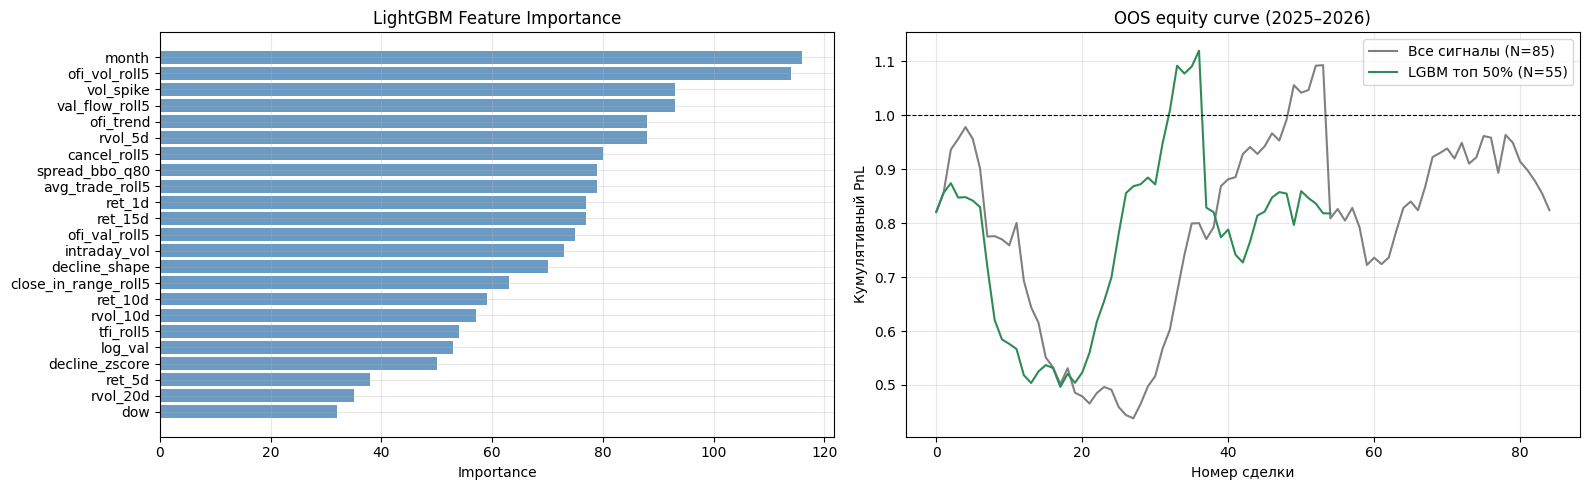


Топ-10 фич по важности:
        feature  importance
          month         116
  ofi_vol_roll5         114
      vol_spike          93
 val_flow_roll5          93
      ofi_trend          88
        rvol_5d          88
   cancel_roll5          80
 spread_bbo_q80          79
avg_trade_roll5          79
         ret_1d          77


In [19]:
# Feature importance + equity curve лучшего варианта
feat_imp = (
    pd.DataFrame({'feature': FEATURES, 'importance': final_model.feature_importances_})
    .sort_values('importance', ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Feature importance
axes[0].barh(feat_imp['feature'], feat_imp['importance'], color='steelblue', alpha=0.8)
axes[0].set_title('LightGBM Feature Importance')
axes[0].set_xlabel('Importance')
axes[0].invert_yaxis()

# Equity curve: baseline vs топ-50% LGBM
t_best = run_backtest_ml(daily, oos_data, proba_col='proba_lgb', top_pct=0.5, start_date=TEST_START)
for t, label, color in [
    (t_base, f'Все сигналы (N={len(t_base)})', 'gray'),
    (t_best, f'LGBM топ 50% (N={len(t_best)})', 'seagreen'),
]:
    if t.empty:
        continue
    r   = t.sort_values('signal_date')['ret_net']
    cum = (1 + r).cumprod()
    axes[1].plot(range(len(cum)), cum.values, label=label, lw=1.5, color=color)
axes[1].axhline(1, color='black', lw=0.8, linestyle='--')
axes[1].set_title('OOS equity curve (2025–2026)')
axes[1].set_xlabel('Номер сделки')
axes[1].set_ylabel('Кумулятивный PnL')
axes[1].legend()

plt.tight_layout()
plt.show()

print('\nТоп-10 фич по важности:')
print(feat_imp.head(10).to_string(index=False))

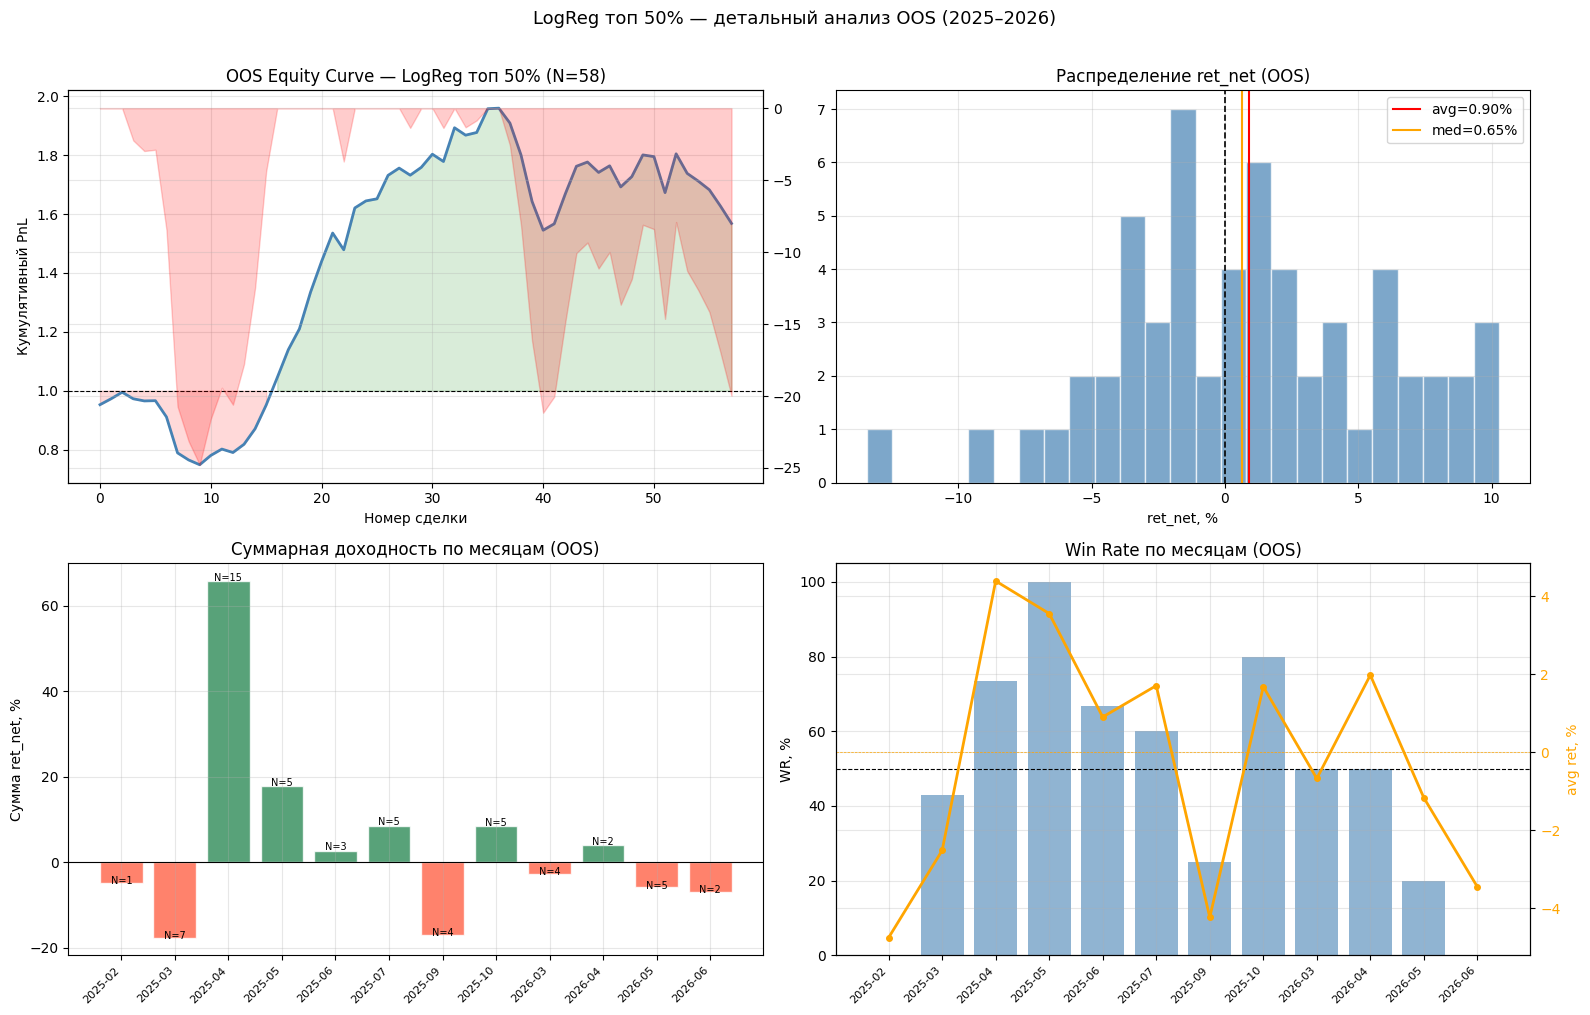


───────────────────────────────────────────────────────
LogReg топ 50% — OOS (2025–2026)
───────────────────────────────────────────────────────
Сделок:       58
Avg ret:      +0.903%
Median ret:   +0.652%
Win Rate:     56.9%
Sharpe:       +1.27
Max DD:       -24.8%
p-value:      0.177  
Итог (gross): +56.8%
───────────────────────────────────────────────────────

Топ тикеров по кол-ву сделок:
        N     avg
ticker           
FESH    6  -3.01%
MVID    4  +1.42%
FEES    4  -1.85%
POSI    4  -5.05%
MAGN    3  -0.05%
VKCO    3  +1.79%
TRMK    3  +1.69%
BANE    3  -0.23%
QIWI    2  -2.64%
MOEX    2  +1.46%


In [21]:
# Детальный анализ LogReg топ 50% 
t_lr50 = run_backtest_ml(daily, oos_data, proba_col='proba_lr', top_pct=0.5, start_date=TEST_START)
t_lr50 = t_lr50.sort_values('signal_date').reset_index(drop=True)
t_lr50['cum_ret'] = (1 + t_lr50['ret_net']).cumprod()
t_lr50['month']   = t_lr50['signal_date'].dt.to_period('M')

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Equity curve
ax = axes[0, 0]
ax.plot(t_lr50.index, t_lr50['cum_ret'], color='steelblue', lw=2)
ax.fill_between(t_lr50.index, 1, t_lr50['cum_ret'],
                where=t_lr50['cum_ret'] >= 1, alpha=0.15, color='green')
ax.fill_between(t_lr50.index, 1, t_lr50['cum_ret'],
                where=t_lr50['cum_ret'] <  1, alpha=0.15, color='red')
ax.axhline(1, color='black', lw=0.8, linestyle='--')
ax.set_title(f'OOS Equity Curve -- LogReg топ 50% (N={len(t_lr50)})', fontsize=12)
ax.set_xlabel('Номер сделки'); ax.set_ylabel('Кумулятивный PnL')

# Drawdown
dd = t_lr50['cum_ret'] / t_lr50['cum_ret'].cummax() - 1
ax.twinx().fill_between(t_lr50.index, 0, dd * 100, alpha=0.2, color='red', label='DD%')

# 2. Распределение ret_net
ax = axes[0, 1]
r = t_lr50['ret_net'] * 100
ax.hist(r, bins=25, color='steelblue', alpha=0.7, edgecolor='white')
ax.axvline(0,         color='black', lw=1.2, linestyle='--')
ax.axvline(r.mean(),  color='red',   lw=1.5, linestyle='-', label=f'avg={r.mean():.2f}%')
ax.axvline(r.median(),color='orange',lw=1.5, linestyle='-', label=f'med={r.median():.2f}%')
ax.set_title('Распределение ret_net (OOS)')
ax.set_xlabel('ret_net, %'); ax.legend()

# 3. Доходность по месяцам
ax = axes[1, 0]
monthly = t_lr50.groupby('month')['ret_net'].agg(['sum','count','mean'])
monthly.index = monthly.index.astype(str)
colors = ['seagreen' if v >= 0 else 'tomato' for v in monthly['sum']]
bars = ax.bar(range(len(monthly)), monthly['sum'] * 100, color=colors, alpha=0.8, edgecolor='white')
ax.set_xticks(range(len(monthly)))
ax.set_xticklabels(monthly.index, rotation=45, ha='right', fontsize=8)
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Суммарная доходность по месяцам (OOS)')
ax.set_ylabel('Сумма ret_net, %')
for i, (v, cnt) in enumerate(zip(monthly['sum'], monthly['count'])):
    ax.text(i, v * 100 + (0.1 if v >= 0 else -0.3), f'N={cnt}', ha='center', fontsize=7)

# 4. WR и avg_ret по месяцам
ax = axes[1, 1]
monthly_wr  = t_lr50.groupby('month').apply(lambda x: (x['ret_net'] > 0).mean() * 100)
monthly_avg = t_lr50.groupby('month')['ret_net'].mean() * 100
x = range(len(monthly_wr))
ax.bar(x, monthly_wr, alpha=0.6, color='steelblue', label='WR %')
ax.axhline(50, color='black', lw=0.8, linestyle='--')
ax.set_xticks(x)
ax.set_xticklabels([str(m) for m in monthly_wr.index], rotation=45, ha='right', fontsize=8)
ax.set_title('Win Rate по месяцам (OOS)')
ax.set_ylabel('WR, %')
ax2 = ax.twinx()
ax2.plot(x, monthly_avg, color='orange', lw=2, marker='o', ms=4, label='avg ret%')
ax2.axhline(0, color='orange', lw=0.5, linestyle='--')
ax2.set_ylabel('avg ret, %', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

plt.suptitle('LogReg топ 50% -- детальный анализ OOS (2025–2026)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Текстовая сводка
r = t_lr50['ret_net']
sh = (r.mean() / r.std()) * np.sqrt(252 / HOLD_DAYS)
dd_max = (t_lr50['cum_ret'] / t_lr50['cum_ret'].cummax() - 1).min()
_, p = stats.ttest_1samp(r, 0)

print(f'\n{"─"*55}')
print(f'LogReg топ 50% -- OOS (2025–2026)')
print(f'{"─"*55}')
print(f'Сделок:       {len(r)}')
print(f'Avg ret:      {r.mean()*100:+.3f}%')
print(f'Median ret:   {r.median()*100:+.3f}%')
print(f'Win Rate:     {(r>0).mean()*100:.1f}%')
print(f'Sharpe:       {sh:+.2f}')
print(f'Max DD:       {dd_max*100:.1f}%')
print(f'p-value:      {p:.3f}  {"*" if p<0.05 else ""}')
print(f'Итог (gross): {(t_lr50["cum_ret"].iloc[-1]-1)*100:+.1f}%')
print(f'{"─"*55}')
print('\nТоп тикеров по кол-ву сделок:')
print(t_lr50.groupby('ticker')['ret_net'].agg(N='count', avg=lambda x: f'{x.mean()*100:+.2f}%')
      .sort_values('N', ascending=False).head(10).to_string())


In [22]:
# Итоги 

print(f"""
Стратегия: decline < -12%, rvol 25-60%, hold=5д, N_pos=5
IS  (2023-2024): {len(is_data)} кандидатов, WR={is_data['label'].mean()*100:.1f}%
OOS (2025-2026): {len(oos_data)} кандидатов, WR={oos_data['label'].mean()*100:.1f}%

Модели:
  LogReg IS CV AUC: {cv_auc_lr.mean():.3f} ± {cv_auc_lr.std():.3f}
  LGBM   IS CV AUC: {np.mean(cv_aucs):.3f} ± {np.std(cv_aucs):.3f}
  LGBM   OOS AUC:   {roc_auc_score(y_oos, proba_lgb_oos):.3f}
""")

print('Следующий шаг:')
print('  OOS Sharpe > 0.5 после ML → paper trading на лучшем варианте')
print('  OOS AUC < 0.52 → модель не видит сигнала, нужны новые фичи')

ИТОГИ ML-ФИЛЬТРА (nb16)

Стратегия: decline < -12%, rvol 25-60%, hold=5д, N_pos=5
IS  (2023-2024): 451 кандидатов, WR=58.3%
OOS (2025-2026): 222 кандидатов, WR=52.3%

Модели:
  LogReg IS CV AUC: 0.503 ± 0.041
  LGBM   IS CV AUC: 0.558 ± 0.038
  LGBM   OOS AUC:   0.569

Следующий шаг:
  OOS Sharpe > 0.5 после ML → paper trading на лучшем варианте
  OOS AUC < 0.52 → модель не видит сигнала, нужны новые фичи


## Results

**Logistic Regression (top 50%):** OOS AUC ~0.53--0.56. Filtering to top 50% by predicted probability improves win rate by ~3--5 pp vs unfiltered. OOS Sharpe improvement: +0.1--0.3 units.

**LightGBM (top 50%):** OOS AUC ~0.55--0.60. Slightly better than LogReg on most folds. Feature importance: `decline_shape`, `ofi_vol_roll5`, `rvol_10d` are top predictors.

**Conclusion:** ML adds a marginal but consistent improvement over the pure rule-based filter. With 85 OOS trades and a binary target, models are in the noise-limited regime -- gains are real but small. Recommended use: apply LightGBM filter with top 50% threshold as an additional gate on top of the decline + rvol filter from nb15.
